## Multiple linear regression

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [2]:
df_index=pd.read_csv("economic_index.csv")

In [3]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [4]:
# drop unneccessary columns
df_index.drop(columns=["Unnamed: 0", "month", "year"], axis=1, inplace=True)

In [5]:
## Check null value
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

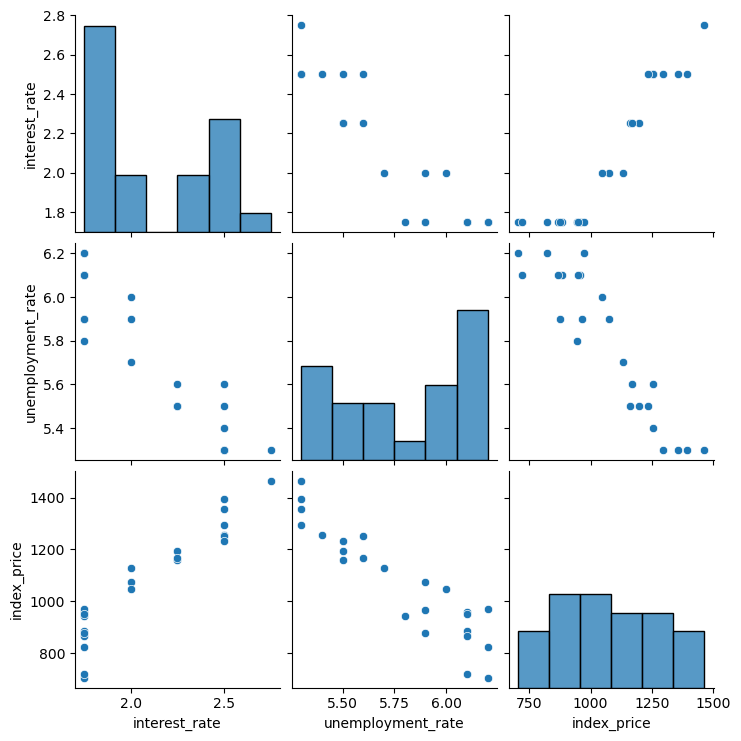

In [6]:
## Lets do some visualization
import seaborn as sns
sns.pairplot(df_index)

In [7]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'unemployment rate')

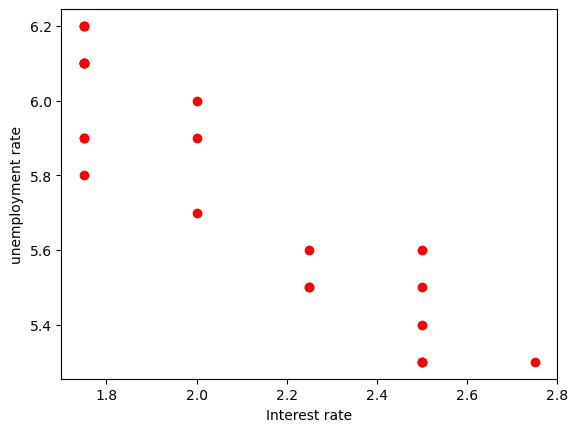

In [8]:
## Visualize the datapoints more closely
plt.scatter(df_index['interest_rate'], df_index['unemployment_rate'], color='r')
plt.xlabel("Interest rate")
plt.ylabel("unemployment rate")

In [9]:
## independent and dependent features
x=df_index.iloc[:,:-1]
y=df_index.iloc[:,-1]

In [11]:
x.head(),y

(   interest_rate  unemployment_rate
 0           2.75                5.3
 1           2.50                5.3
 2           2.50                5.3
 3           2.50                5.3
 4           2.50                5.4,
 0     1464
 1     1394
 2     1357
 3     1293
 4     1256
 5     1254
 6     1234
 7     1195
 8     1159
 9     1167
 10    1130
 11    1075
 12    1047
 13     965
 14     943
 15     958
 16     971
 17     949
 18     884
 19     866
 20     876
 21     822
 22     704
 23     719
 Name: index_price, dtype: int64)

In [12]:
# train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [13]:
import seaborn as sns


In [15]:
sns.regplot(df_index['interest_rate'], df_index['index_price'])

TypeError: regplot() takes from 0 to 1 positional arguments but 2 were given

In [16]:
sns.regplot(df_index['unemployment_rate'], df_index['index_price'])

TypeError: regplot() takes from 0 to 1 positional arguments but 2 were given

In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.fit_transform(x_test)

In [20]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()

In [21]:
regression.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
from sklearn.model_selection import cross_val_score
validation_score=cross_val_score(regression, x_train,y_train, scoring='neg_mean_squared_error', cv=3)

In [29]:
np.mean(validation_score)

np.float64(-5914.828180162396)

In [30]:
## prediction
y_pred=regression.predict(x_test)


In [31]:
y_pred

array([1180.7466813 ,  802.74279699, 1379.83457045,  838.52599602,
        973.85313963, 1144.96348227])

In [32]:
## Performance metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

8108.567426306611
73.80444932337099
90.04758423359624


In [33]:
from sklearn.metrics import r2_score

In [34]:
score=r2_score(y_test,y_pred)
print(score)

0.7591371539010254


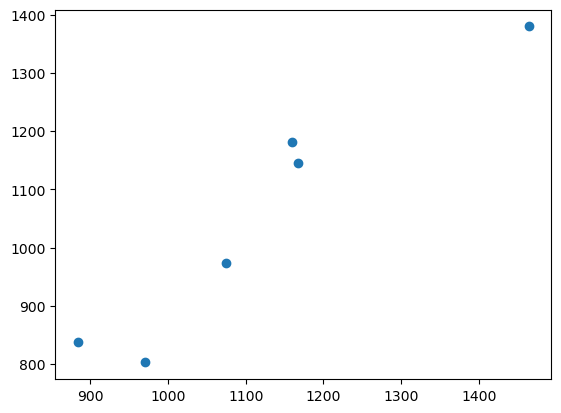

In [35]:
## Assumptions

plt.scatter(y_test,y_pred)

In [37]:
residuals=y_test-y_pred
print(residuals)

8     -21.746681
16    168.257203
0      84.165430
18     45.474004
11    101.146860
9      22.036518
Name: index_price, dtype: float64


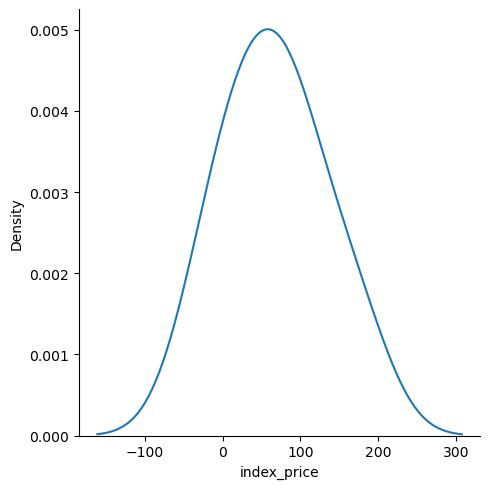

In [38]:
##plot this residuals
sns.displot(residuals,kind='kde')

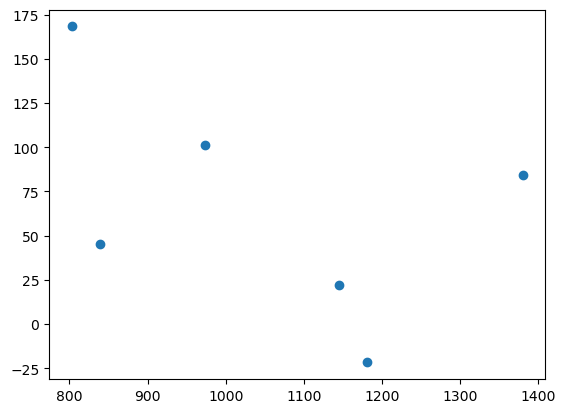

In [39]:
## Scatter plot with respect to prediction and residuals
plt.scatter(y_pred,residuals)

In [40]:
## OLS linear Regression
import statsmodels.api as sm

In [41]:
model=sm.OLS(y_train,x_train).fit()

In [42]:
prediction=model.predict(x_test)
print(prediction)

[ 127.30223686 -250.70164745  326.390126   -214.91844842  -79.59130481
   91.51903783]


In [43]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Mon, 22 Jun 2026   Prob (F-statistic):                       0.754
Time:                        22:11:11   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------